In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,SystemMessage,HumanMessage

In [4]:
from typing import TypedDict,Annotated

In [5]:
class chatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [6]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [8]:
def get_response(state:chatState):
    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages':[response.content]}

In [9]:
graph = StateGraph(state_schema=chatState)
graph.add_node('call llm',get_response)
graph.add_edge(START,'call llm')
graph.add_edge('call llm',END)

workflow = graph.compile()

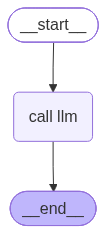

In [10]:
workflow

In [11]:
workflow.invoke({
    'messages':[HumanMessage(content='who is the pm of nepal')]
})

{'messages': [HumanMessage(content='who is the pm of nepal', additional_kwargs={}, response_metadata={}, id='d5dbd419-3820-4338-b7a9-8500e10b82ed'),
  HumanMessage(content='As of my last knowledge update in October 2023, Pushpa Kamal Dahal, also known as Prachanda, was serving as the Prime Minister of Nepal. However, please verify this information with up-to-date sources, as political situations can change rapidly.', additional_kwargs={}, response_metadata={}, id='29a483ff-07b0-4f4c-beaa-7bec69f29d4a')]}

In [15]:
while True:
    user_input = input('enter your query')

    if user_input.strip().lower() in ['exit','bye','finish']:
        break

    print(f'you : {user_input}')
    messages = [HumanMessage(content=user_input)]
    response = workflow.invoke({'messages':messages})
    print('bot:', response['messages'][-1].content)

you : hi my country name is nepal
bot: Hello! It's great to hear from you. Nepal is a beautiful country known for its stunning landscapes, including the Himalayas and Mount Everest, as well as its rich culture and history. Do you have any specific questions or topics related to Nepal that you'd like to discuss?
you : what is my country name
bot: I'm sorry, but I don't have access to personal data about individuals unless it has been shared with me in the course of our conversation. Therefore, I can't determine your country name. If you'd like to share your country, feel free to do so!


####  till now the llm does not have any type of the memory so we need to implement a simple type of the memory